# Eksploracyjna Analiza Danych (EDA) - Książki i Oceny Użytkowników

W tym notatniku przeprowadzimy analizę dwóch próbek zbiorów danych Goodreads:

[kaggle dataset](https://www.kaggle.com/datasets/bahramjannesarr/goodreads-book-datasets-10m?resource=download)

1. **books.csv** (0-100k) - zawiera szczegółowe informacje o książkach (autorzy, liczba stron, rok wydania, średnia ocena itp.).

2. **user_ratings.csv** (0-100k) - zawiera oceny konkretnych książek wystawione przez użytkowników.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Konfiguracja wizualizacji
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Wczytanie danych
Wczytujemy oba pliki CSV i sprawdzamy ich podstawowe parametry.

In [12]:
# Wczytanie danych
books_df = pd.read_csv('data/books.csv')
ratings_df = pd.read_csv('data/user_ratings.csv')

print(f"Wymiary zbioru books: {books_df.shape}")
print(f"Wymiary zbioru ratings: {ratings_df.shape}")

Wymiary zbioru books: (58292, 18)
Wymiary zbioru ratings: (51945, 3)


## 1.1 Opis źródeł danych

Analiza opiera się na dwóch powiązanych zbiorach danych pochodzących z serwisu Goodreads:

1. **books.csv**:
   - Zawiera metadane dla ponad 58 000 pozycji książkowych.
   - **Kluczowe kolumny:** `Name` (tytuł), `Authors` (autorzy), `Rating` (średnia ocena), `pagesNumber` (liczba stron) oraz szczegółowe rozkłady ocen (`RatingDist1-5`).
   - Dane te pozwalają na analizę trendów wydawniczych oraz popularności autorów.
   - dostępne są także krótkie opisy książek `Description`

2. **user_ratings.csv**:
   - Zawiera ~ 52 000 indywidualnych interakcji użytkowników.
   - **Kluczowe kolumny:** `ID` (anonimowy identyfikator użytkownika), `Name` (tytuł książki) oraz `Rating` (ocena opisowa).
   - Unikalną cechą tego zbioru jest tekstowa forma oceny (np. "it was amazing", "liked it")

## 2. Podstawowy przegląd danych
Spójrzmy na pierwsze wiersze oraz typy danych w obu tabelach, a także sprawdźmy ewentualne braki.

In [13]:
display(books_df.head(3))
display(books_df.info())

,Id,Name,RatingDist1,pagesNumber,RatingDist4,RatingDistTotal,PublishMonth,PublishDay,Publisher,CountsOfReview,PublishYear,Language,Authors,Rating,RatingDist2,RatingDist5,ISBN,RatingDist3
0,1,Harry Potter and the Half-Blood Prince (Harry ...,1:9896,652,4:556485,total:2298124,16,9,Scholastic Inc.,28062,2006,eng,J.K. Rowling,4.57,2:25317,5:1546466,NaN,3:159960
1,2,Harry Potter and the Order of the Phoenix (Har...,1:12455,870,4:604283,total:2358637,1,9,Scholastic Inc.,29770,2004,eng,J.K. Rowling,4.50,2:37005,5:1493113,0439358078,3:211781
2,3,Harry Potter and the Sorcerer's Stone (Harry P...,1:108202,309,4:1513191,total:6587388,1,11,Scholastic Inc,75911,2003,eng,J.K. Rowling,4.47,2:130310,5:4268227,NaN,3:567458


<class 'pandas.DataFrame'>
RangeIndex: 58292 entries, 0 to 58291
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Id               58292 non-null  int64  
 1   Name             58292 non-null  str    
 2   RatingDist1      58292 non-null  str    
 3   pagesNumber      58292 non-null  int64  
 4   RatingDist4      58292 non-null  str    
 5   RatingDistTotal  58292 non-null  str    
 6   PublishMonth     58292 non-null  int64  
 7   PublishDay       58292 non-null  int64  
 8   Publisher        57798 non-null  str    
 9   CountsOfReview   58292 non-null  int64  
 10  PublishYear      58292 non-null  int64  
 11  Language         20294 non-null  str    
 12  Authors          58292 non-null  str    
 13  Rating           58292 non-null  float64
 14  RatingDist2      58292 non-null  str    
 15  RatingDist5      58292 non-null  str    
 16  ISBN             57746 non-null  str    
 17  RatingDist3      58292 

None

In [14]:
# Sprawdzenie braków danych
print("Braki danych w books_df:")
print(books_df.isnull().sum()[books_df.isnull().sum() > 0])

print("\nBraki danych w ratings_df:")
print(ratings_df.isnull().sum()[ratings_df.isnull().sum() > 0])

Braki danych w books_df:
Publisher      494
Language     37998
ISBN           546
dtype: int64

Braki danych w ratings_df:
Series([], dtype: int64)


## 3. Analiza zbioru Książek (`books.csv`)
Zbadamy rozkład ocen, długość książek oraz najpopularniejszych autorów.

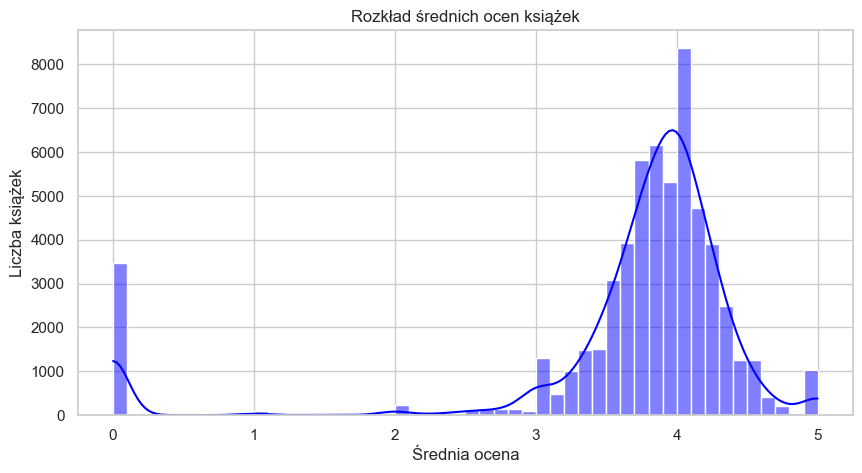

In [15]:
# Rozkład średnich ocen książek
plt.figure(figsize=(10, 5))
sns.histplot(books_df['Rating'], bins=50, kde=True, color='blue')
plt.title('Rozkład średnich ocen książek')
plt.xlabel('Średnia ocena')
plt.ylabel('Liczba książek')
plt.show()

C:\Users\patik\AppData\Local\Temp\ipykernel_20672\2927389590.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_authors.index, x=top_authors.values, palette='viridis')


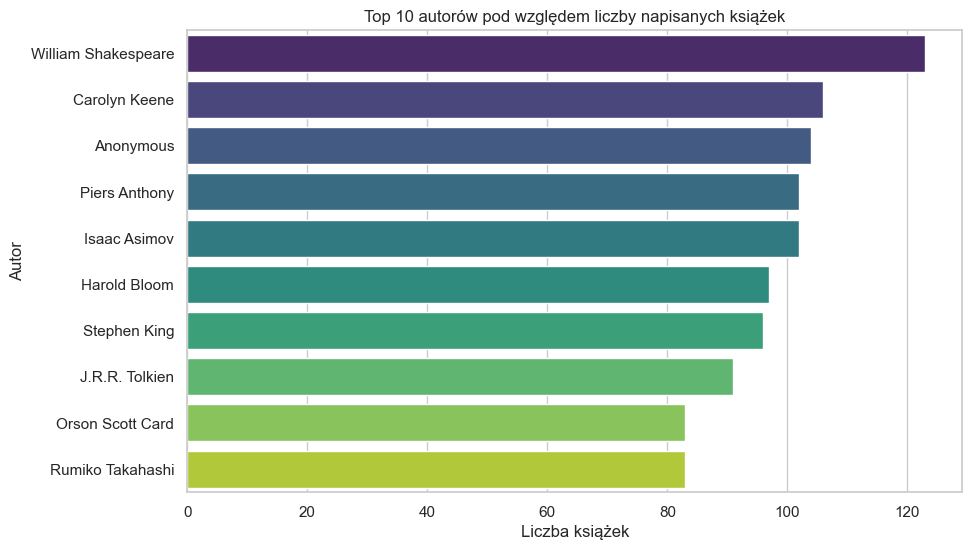

In [16]:
# Top 10 autorów z największą liczbą książek
top_authors = books_df['Authors'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(y=top_authors.index, x=top_authors.values, palette='viridis')
plt.title('Top 10 autorów pod względem liczby napisanych książek')
plt.xlabel('Liczba książek')
plt.ylabel('Autor')
plt.show()

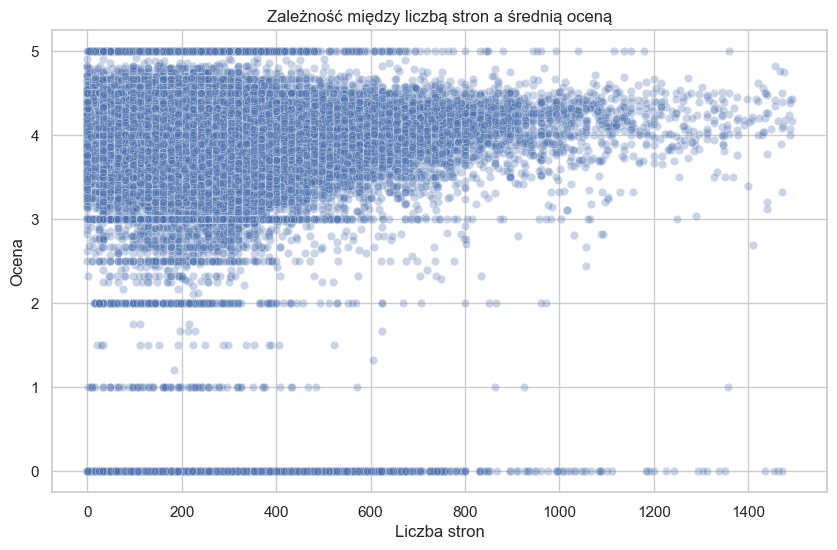

In [17]:
# Zależność między liczbą stron a oceną (dla książek poniżej 1500 stron, aby wykluczyć outliery)
books_filtered = books_df[books_df['pagesNumber'] < 1500]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=books_filtered, x='pagesNumber', y='Rating', alpha=0.3)
plt.title('Zależność między liczbą stron a średnią oceną')
plt.xlabel('Liczba stron')
plt.ylabel('Ocena')
plt.show()

## 4. Analiza ocen użytkowników (`user_ratings.csv`)
Zauważmy, że w tym zbiorze oceny mają format tekstowy (np. "it was amazing", "really liked it"). Zobaczmy, jak się rozkładają.

C:\Users\patik\AppData\Local\Temp\ipykernel_20672\553094071.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.values, y=rating_counts.index, palette='magma')


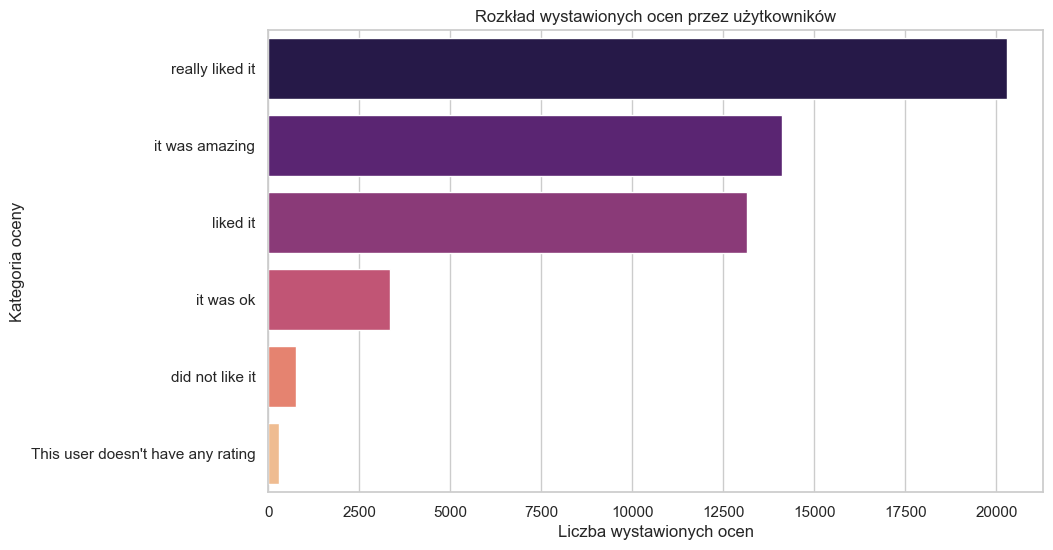

In [18]:
# Rozkład ocen tekstowych
rating_counts = ratings_df['Rating'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=rating_counts.values, y=rating_counts.index, palette='magma')
plt.title('Rozkład wystawionych ocen przez użytkowników')
plt.xlabel('Liczba wystawionych ocen')
plt.ylabel('Kategoria oceny')
plt.show()

System mapowania wygląda następująco:

 - 5 gwiazdek = "it was amazing" (była niesamowita)

 - 4 gwiazdki = "really liked it" (bardzo mi się podobała)

 - 3 gwiazdki = "liked it" (podobała mi się)

 - 2 gwiazdki = "it was ok" (była w porządku)

 - 1 gwiazdka = "did not like it" (nie podobała mi się)

In [19]:
# Sprawdzenie aktywności użytkowników (Top 10 użytkowników z największą liczbą ocen)
top_users = ratings_df['ID'].value_counts().head(10)
print("Top 10 najbardziej aktywnych użytkowników (ID : liczba ocen):")
print(top_users)

Top 10 najbardziej aktywnych użytkowników (ID : liczba ocen):
ID
284    2052
675    1244
853    1082
913     999
166     995
338     993
882     938
529     890
926     758
5       703
Name: count, dtype: int64


## 5. Połączenie zbiorów
Jeżeli chcemy dowiedzieć się więcej o ocenianych książkach, możemy połączyć tabele używając nazwy książki (`Name`).

In [20]:
# Łączymy oceny użytkowników z danymi o książkach
merged_df = pd.merge(ratings_df, books_df[['Name', 'Authors', 'PublishYear', 'Language']], on='Name', how='inner')

print(f"Wymiary połączonego zbioru: {merged_df.shape}")
display(merged_df.head())

Wymiary połączonego zbioru: (26348, 6)


,ID,Name,Rating,Authors,PublishYear,Language
0,1,Agile Web Development with Rails: A Pragmatic ...,it was amazing,Dave Thomas,2005,eng
1,1,The Restaurant at the End of the Universe (Hit...,it was amazing,Douglas Adams,2005,eng
2,1,Siddhartha,it was amazing,Hermann Hesse,2004,NaN
3,1,Siddhartha,it was amazing,Hermann Hesse,2000,NaN
4,1,"The Clue in the Embers (Hardy Boys, #35)",it was amazing,Franklin W. Dixon,1956,eng
